# Aula de Linha de Regressão — Trabalho Completo
### Comparação: Regressão Linear × SVM × GPR
**Dataset:** Iris | **Alvo:** Predição de Petal Width a partir de Petal Length

---
## PARTE 1 — Código original do professor (mantido sem alterações)

In [35]:
# ==========================================================
# VERIFICAÇÃO E INSTALAÇÃO AUTOMÁTICA DE DEPENDÊNCIAS
# ==========================================================

import sys
import subprocess
import importlib

# Dicionário:
# chave   -> nome do pacote no pip
# valor   -> nome usado no import

print("Interpretador Python em uso:")
print(sys.executable)

# Pacotes necessários para o projeto
pacotes = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn"
}

print("\nVerificando dependências...\n")

for nome_pip, nome_importacao in pacotes.items():

    try:
        importlib.import_module(nome_importacao)
        print(f"[OK] Biblioteca '{nome_pip}' já instalada.")

    except ImportError:
        print(f"[INSTALANDO] Biblioteca '{nome_pip}' não encontrada.")
        
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            nome_pip
        ])
        
        print(f"[SUCESSO] Biblioteca '{nome_pip}' instalada com sucesso.")

Interpretador Python em uso:
d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Scripts\python.exe

Verificando dependências...

[OK] Biblioteca 'pandas' já instalada.
[OK] Biblioteca 'numpy' já instalada.
[OK] Biblioteca 'matplotlib' já instalada.
[OK] Biblioteca 'seaborn' já instalada.
[OK] Biblioteca 'scikit-learn' já instalada.


In [36]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_iris

# Divisão de dados
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Modelos de regressão
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Métricas
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

# Controle de tempo computacional
import time

# Configuração visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [37]:
print("\nVERSÕES DAS BIBLIOTECAS\n")

print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")


VERSÕES DAS BIBLIOTECAS

Pandas: 3.0.2
Numpy: 2.4.4
Matplotlib: 3.10.8
Seaborn: 0.13.2


In [ ]:
# Configuração visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [38]:
# Carregamento do dataset Iris
iris = load_iris()

# Criação do DataFrame
base_dados = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Variável alvo
base_dados['species'] = iris.target

# Exibição inicial
base_dados.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [39]:
base_dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [40]:
base_dados.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


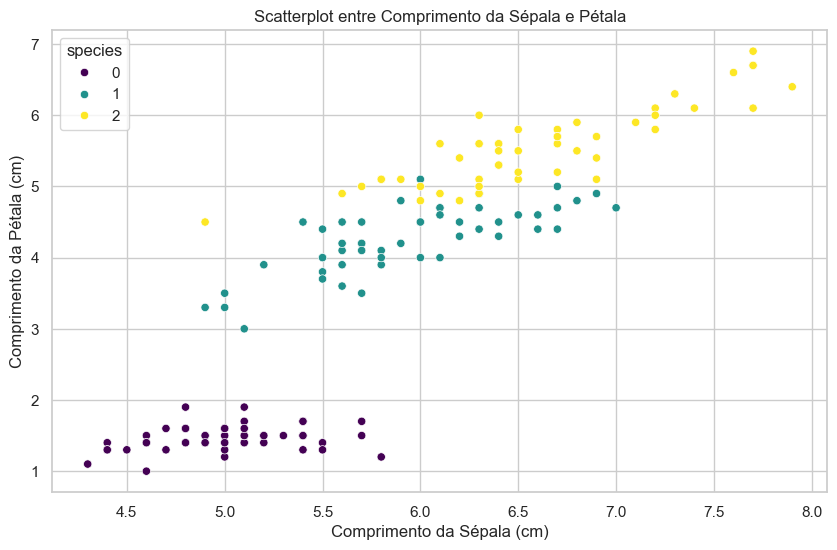

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=base_dados,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species',
    palette='viridis'
)

plt.title('Scatterplot entre Comprimento da Sépala e Pétala')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Comprimento da Pétala (cm)')

plt.show()

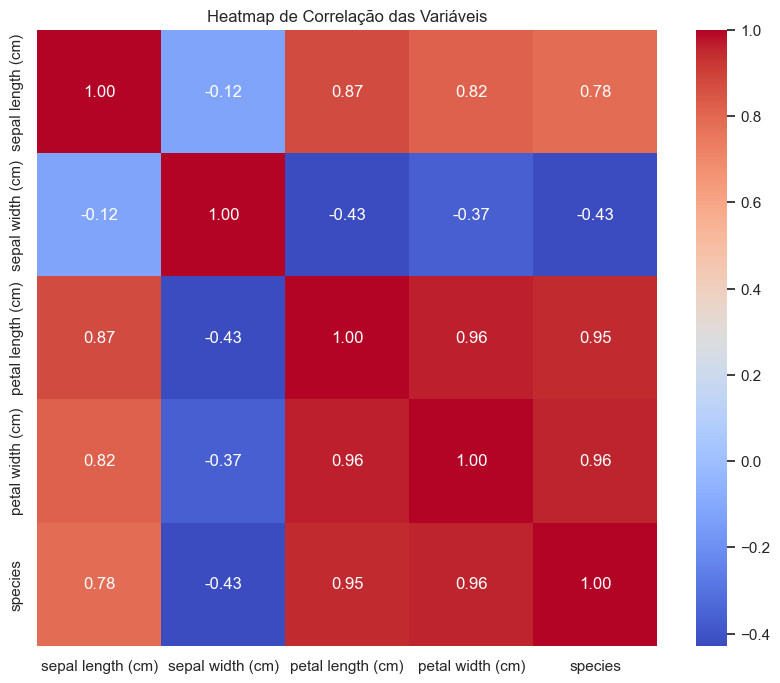

In [42]:
plt.figure(figsize=(10, 8))

matriz_correlacao = base_dados.corr(numeric_only=True)

sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap de Correlação das Variáveis')

plt.show()

In [43]:
X = base_dados[['sepal length (cm)']]
y = base_dados['petal length (cm)']

In [44]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
inicio_linear = time.time()

modelo_linear = LinearRegression()
modelo_linear.fit(X_treino, y_treino)

fim_linear = time.time()

tempo_linear = fim_linear - inicio_linear

In [46]:
y_pred_linear = modelo_linear.predict(X_teste)

In [47]:
r2_linear = r2_score(y_teste, y_pred_linear)
mae_linear = mean_absolute_error(y_teste, y_pred_linear)
mse_linear = mean_squared_error(y_teste, y_pred_linear)
rmse_linear = root_mean_squared_error(y_teste, y_pred_linear)

print('REGRESSÃO LINEAR')
print(f'R²: {r2_linear:.4f}')
print(f'MAE: {mae_linear:.4f}')
print(f'MSE: {mse_linear:.4f}')
print(f'RMSE: {rmse_linear:.4f}')
print(f'Tempo de treinamento: {tempo_linear:.6f} segundos')

REGRESSÃO LINEAR
R²: 0.8181
MAE: 0.6165
MSE: 0.5961
RMSE: 0.7721
Tempo de treinamento: 0.002770 segundos


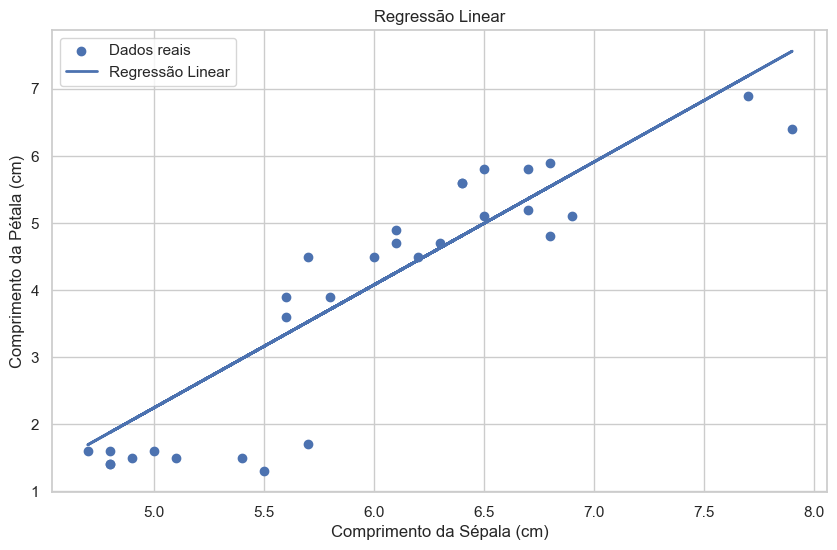

In [48]:
plt.figure(figsize=(10, 6))

plt.scatter(X_teste, y_teste, label='Dados reais')
plt.plot(X_teste, y_pred_linear, linewidth=2, label='Regressão Linear')

plt.title('Regressão Linear')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Comprimento da Pétala (cm)')

plt.legend()
plt.show()

In [49]:
inicio_svr = time.time()

modelo_svr = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=100, epsilon=0.1)
)

modelo_svr.fit(X_treino, y_treino)

fim_svr = time.time()

tempo_svr = fim_svr - inicio_svr

In [50]:
y_pred_svr = modelo_svr.predict(X_teste)

In [51]:
r2_svr = r2_score(y_teste, y_pred_svr)
mae_svr = mean_absolute_error(y_teste, y_pred_svr)
mse_svr = mean_squared_error(y_teste, y_pred_svr)
rmse_svr = root_mean_squared_error(y_teste, y_pred_svr)

print('SUPPORT VECTOR REGRESSION')
print(f'R²: {r2_svr:.4f}')
print(f'MAE: {mae_svr:.4f}')
print(f'MSE: {mse_svr:.4f}')
print(f'RMSE: {rmse_svr:.4f}')
print(f'Tempo de treinamento: {tempo_svr:.6f} segundos')

SUPPORT VECTOR REGRESSION
R²: 0.8394
MAE: 0.4377
MSE: 0.5264
RMSE: 0.7256
Tempo de treinamento: 0.012672 segundos


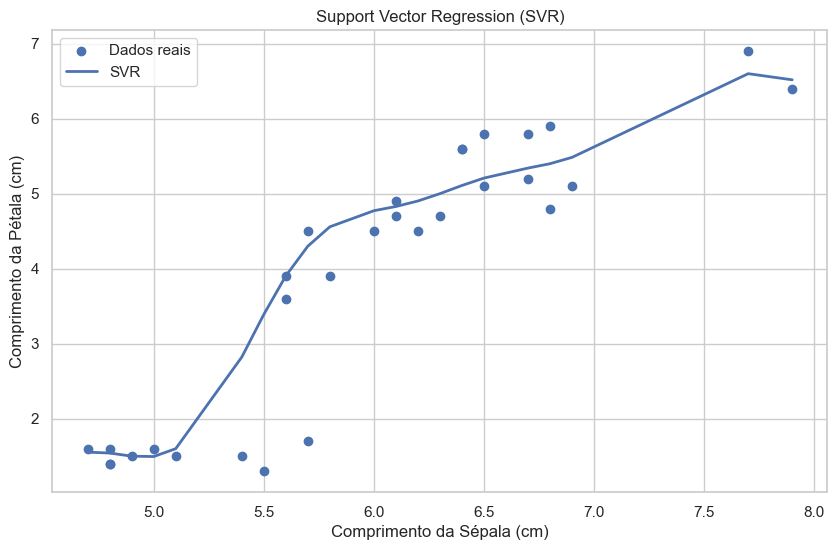

In [52]:
indices_ordenados = np.argsort(X_teste.values.flatten())

X_ordenado = X_teste.values.flatten()[indices_ordenados]
y_ordenado = y_pred_svr[indices_ordenados]

plt.figure(figsize=(10, 6))

plt.scatter(X_teste, y_teste, label='Dados reais')
plt.plot(X_ordenado, y_ordenado, linewidth=2, label='SVR')

plt.title('Support Vector Regression (SVR)')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Comprimento da Pétala (cm)')

plt.legend()
plt.show()

In [53]:
kernel = RBF(length_scale=1.0)

In [54]:
inicio_gpr = time.time()

modelo_gpr = GaussianProcessRegressor(
    kernel=kernel,
    random_state=42
)

modelo_gpr.fit(X_treino, y_treino)

fim_gpr = time.time()

tempo_gpr = fim_gpr - inicio_gpr

d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [55]:
y_pred_gpr, desvio_padrao = modelo_gpr.predict(
    X_teste,
    return_std=True
)

In [56]:
r2_gpr = r2_score(y_teste, y_pred_gpr)
mae_gpr = mean_absolute_error(y_teste, y_pred_gpr)
mse_gpr = mean_squared_error(y_teste, y_pred_gpr)
rmse_gpr = root_mean_squared_error(y_teste, y_pred_gpr)

print('GAUSSIAN PROCESS REGRESSION')
print(f'R²: {r2_gpr:.4f}')
print(f'MAE: {mae_gpr:.4f}')
print(f'MSE: {mse_gpr:.4f}')
print(f'RMSE: {rmse_gpr:.4f}')
print(f'Tempo de treinamento: {tempo_gpr:.6f} segundos')

GAUSSIAN PROCESS REGRESSION
R²: 0.4259
MAE: 0.7245
MSE: 1.8816
RMSE: 1.3717
Tempo de treinamento: 0.013746 segundos


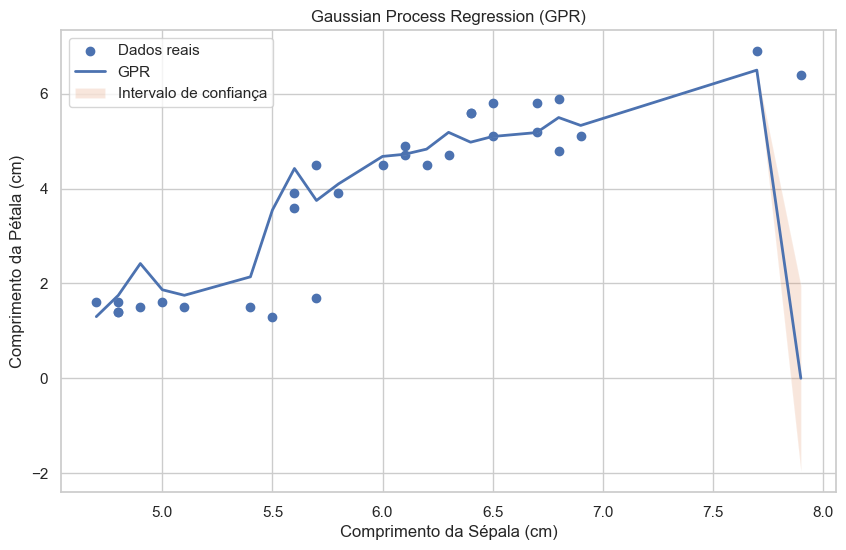

In [57]:
indices_ordenados = np.argsort(X_teste.values.flatten())

X_ordenado = X_teste.values.flatten()[indices_ordenados]
y_ordenado = y_pred_gpr[indices_ordenados]
std_ordenado = desvio_padrao[indices_ordenados]

plt.figure(figsize=(10, 6))

plt.scatter(X_teste, y_teste, label='Dados reais')

plt.plot(
    X_ordenado,
    y_ordenado,
    linewidth=2,
    label='GPR'
)

plt.fill_between(
    X_ordenado,
    y_ordenado - 1.96 * std_ordenado,
    y_ordenado + 1.96 * std_ordenado,
    alpha=0.2,
    label='Intervalo de confiança'
)

plt.title('Gaussian Process Regression (GPR)')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Comprimento da Pétala (cm)')

plt.legend()
plt.show()

In [58]:
scores_linear = cross_val_score(
    modelo_linear,
    X,
    y,
    cv=5,
    scoring='r2'
)

print('Cross Validation - Regressão Linear')
print(scores_linear)
print(f'Média R²: {scores_linear.mean():.4f}')

Cross Validation - Regressão Linear
[-51.52454692   0.52866261  -1.85363774  -0.10127352  -1.87189524]
Média R²: -10.9645


In [59]:
scores_svr = cross_val_score(
    modelo_svr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print('Cross Validation - SVR')
print(scores_svr)
print(f'Média R²: {scores_svr.mean():.4f}')

Cross Validation - SVR
[-38.47205634   0.64098613  -3.335221     0.05194733  -0.56989683]
Média R²: -8.3368


In [60]:
scores_gpr = cross_val_score(
    modelo_gpr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print('Cross Validation - GPR')
print(scores_gpr)
print(f'Média R²: {scores_gpr.mean():.4f}')

Cross Validation - GPR
[-47.26811847   0.0859008   -3.51022798  -4.47817814 -12.07445375]
Média R²: -13.4490


d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Projetos\GitHub\UFPA\transistor-de-fronteira-camtuc\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warning

In [61]:
metricas_modelos = pd.DataFrame({
    'Modelo': ['Linear', 'SVR', 'GPR'],
    'R²': [r2_linear, r2_svr, r2_gpr],
    'MAE': [mae_linear, mae_svr, mae_gpr],
    'MSE': [mse_linear, mse_svr, mse_gpr],
    'RMSE': [rmse_linear, rmse_svr, rmse_gpr]
})

metricas_modelos

,Modelo,R²,MAE,MSE,RMSE
0,Linear,0.818125,0.616541,0.596077,0.772060
1,SVR,0.839370,0.437683,0.526448,0.725567
2,GPR,0.425894,0.724472,1.881569,1.371703


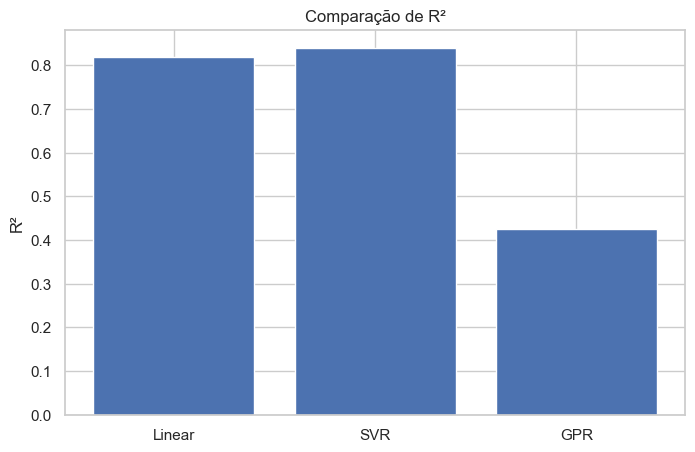

In [62]:
plt.figure(figsize=(8, 5))

plt.bar(metricas_modelos['Modelo'], metricas_modelos['R²'])

plt.title('Comparação de R²')
plt.ylabel('R²')

plt.show()

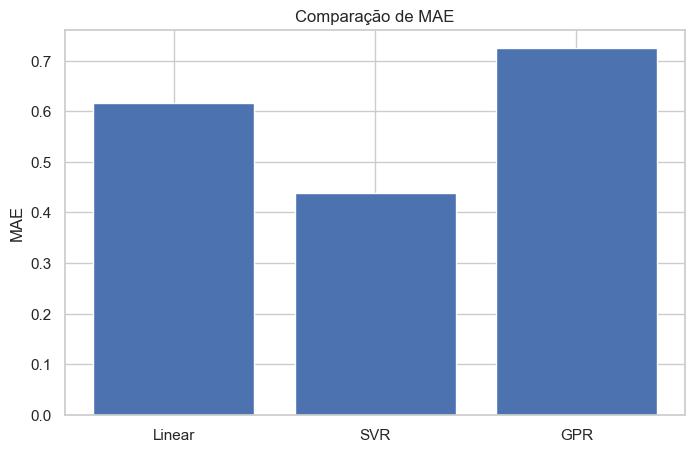

In [63]:
plt.figure(figsize=(8, 5))

plt.bar(metricas_modelos['Modelo'], metricas_modelos['MAE'])

plt.title('Comparação de MAE')
plt.ylabel('MAE')

plt.show()

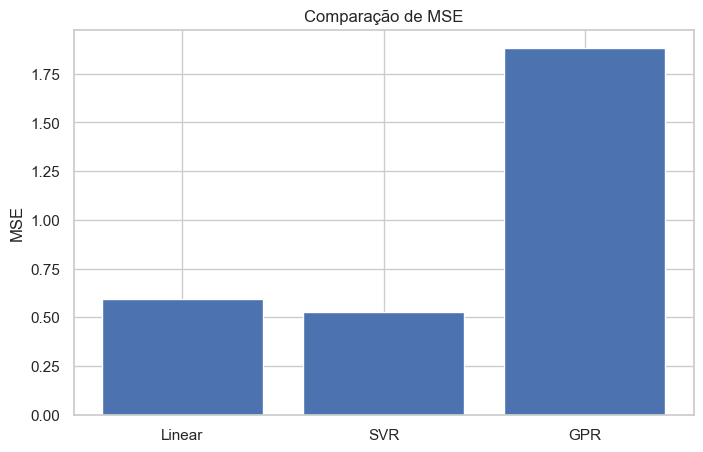

In [64]:
plt.figure(figsize=(8, 5))

plt.bar(metricas_modelos['Modelo'], metricas_modelos['MSE'])

plt.title('Comparação de MSE')
plt.ylabel('MSE')

plt.show()

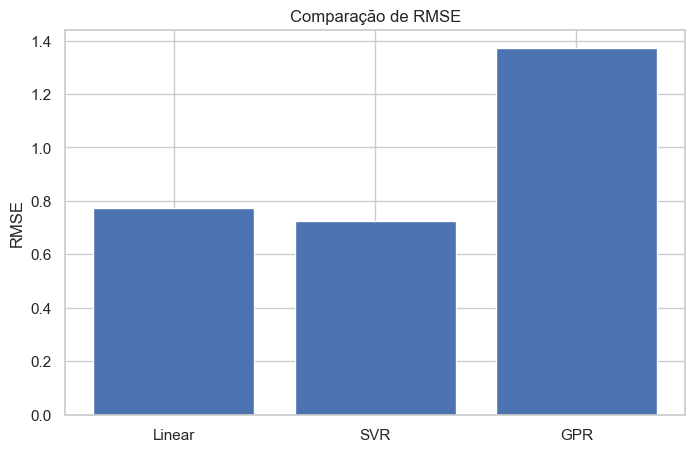

In [65]:
plt.figure(figsize=(8, 5))

plt.bar(metricas_modelos['Modelo'], metricas_modelos['RMSE'])

plt.title('Comparação de RMSE')
plt.ylabel('RMSE')

plt.show()

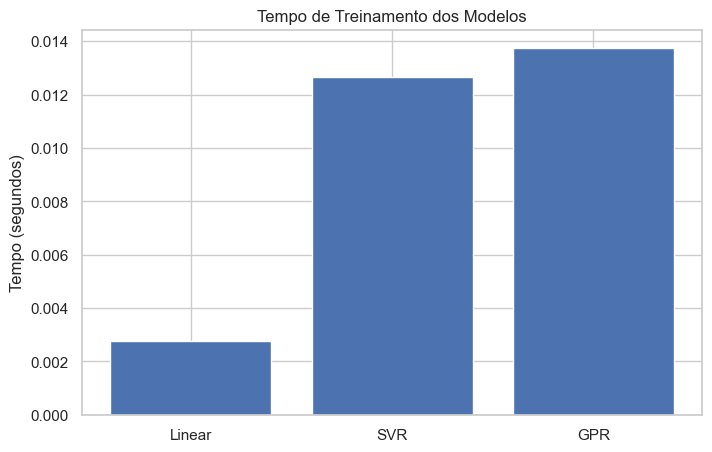

In [66]:
tempos_treinamento = pd.DataFrame({
    'Modelo': ['Linear', 'SVR', 'GPR'],
    'Tempo': [tempo_linear, tempo_svr, tempo_gpr]
})

plt.figure(figsize=(8, 5))

plt.bar(
    tempos_treinamento['Modelo'],
    tempos_treinamento['Tempo']
)

plt.title('Tempo de Treinamento dos Modelos')
plt.ylabel('Tempo (segundos)')

plt.show()

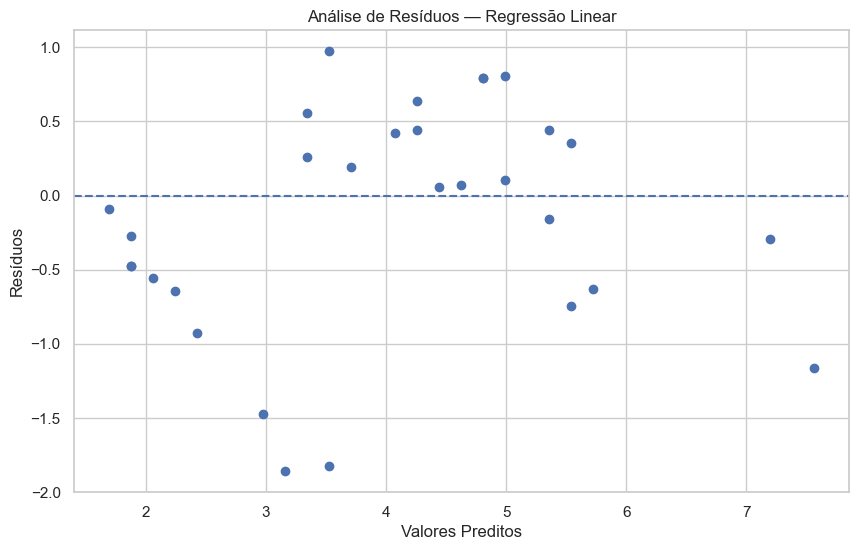

In [67]:
residuos_linear = y_teste - y_pred_linear

plt.figure(figsize=(10, 6))

plt.scatter(y_pred_linear, residuos_linear)
plt.axhline(y=0, linestyle='--')

plt.title('Análise de Resíduos — Regressão Linear')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')

plt.show()

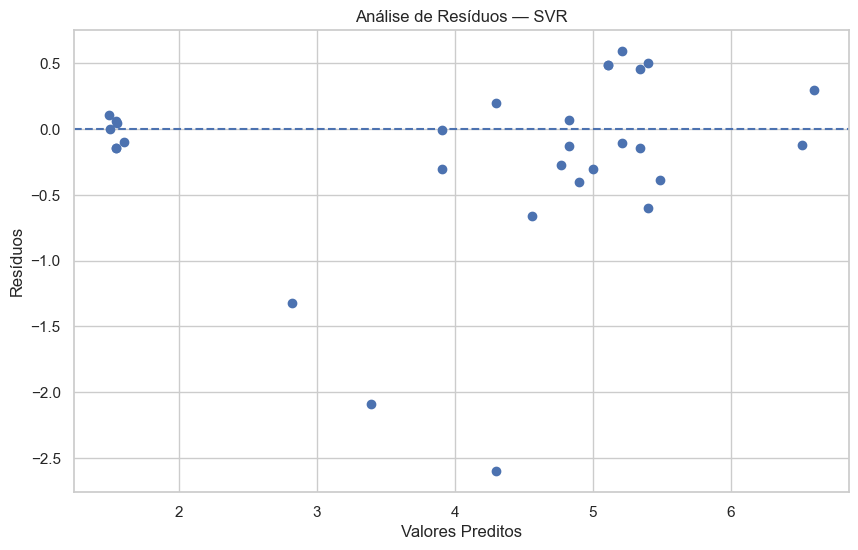

In [68]:
residuos_svr = y_teste - y_pred_svr

plt.figure(figsize=(10, 6))

plt.scatter(y_pred_svr, residuos_svr)
plt.axhline(y=0, linestyle='--')

plt.title('Análise de Resíduos — SVR')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')

plt.show()

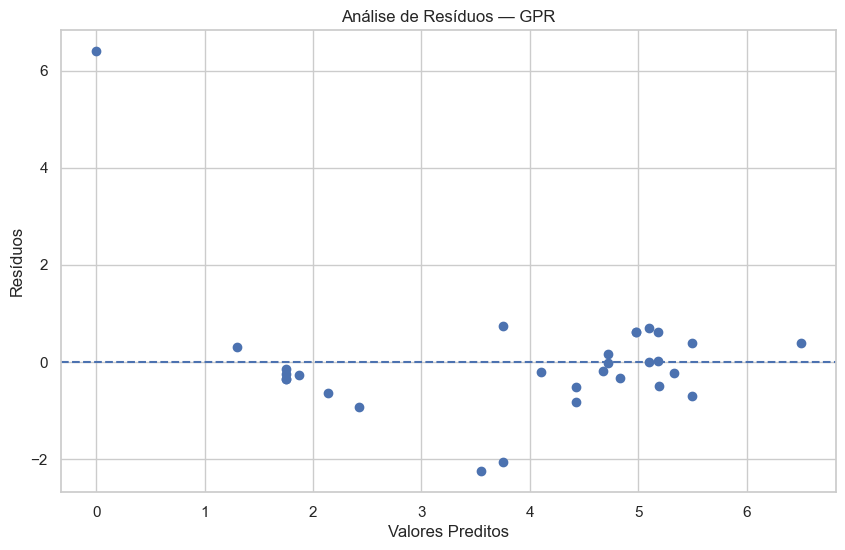

In [69]:
residuos_gpr = y_teste - y_pred_gpr

plt.figure(figsize=(10, 6))

plt.scatter(y_pred_gpr, residuos_gpr)
plt.axhline(y=0, linestyle='--')

plt.title('Análise de Resíduos — GPR')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')

plt.show()